In [26]:
!pip install pandas numpy scikit-learn imbalanced-learn matplotlib seaborn
!pip install pandas numpy scikit-learn imbalanced-learn xgboost matplotlib seaborn

In [27]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Model evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Handle class imbalance
from imblearn.over_sampling import SMOTE

In [28]:
# Load malaria dataset
data = pd.read_csv("Malaria_Dataset.csv", encoding='latin1')

# Display first rows
print(data.head())

# Display dataset shape
print("Dataset shape:", data.shape)

# Display column names
print(data.columns)

   Age Gender (F/M) PregNAPPnt Status (PW/NPW/NAPP)  Temp (°C)  \
0   22            F                             NPW       36.9   
1   33            M                            NAPP       39.1   
2   47            M                            NAPP       38.6   
3   15            F                             NPW       37.9   
4   25            M                            NAPP       38.5   

  Travel History (Yes/No) Previous Malaria History (Yes/No)  \
0                     Yes                               Yes   
1                      No                               Yes   
2                     Yes                               Yes   
3                      No                                No   
4                      No                                No   

  Result (Positive/Negative)  
0                   Positive  
1                   Positive  
2                   Positive  
3                   Negative  
4                   Positive  
Dataset shape: (550, 7)
Index(['Age', 

In [29]:
# Check dataset information
print(data.info())

# Check missing values
print(data.isnull().sum())

# Summary statistics
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 7 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                550 non-null    int64  
 1   Gender (F/M)                       550 non-null    object 
 2   PregNAPPnt Status (PW/NPW/NAPP)    550 non-null    object 
 3   Temp (°C)                          550 non-null    float64
 4   Travel History (Yes/No)            550 non-null    object 
 5   Previous Malaria History (Yes/No)  550 non-null    object 
 6   Result (Positive/Negative)         550 non-null    object 
dtypes: float64(1), int64(1), object(5)
memory usage: 30.2+ KB
None
Age                                  0
Gender (F/M)                         0
PregNAPPnt Status (PW/NPW/NAPP)      0
Temp (°C)                            0
Travel History (Yes/No)              0
Previous Malaria History (Yes/No)    0
Result (Positive/N

Result (Positive/Negative)
Positive    386
Negative    164
Name: count, dtype: int64


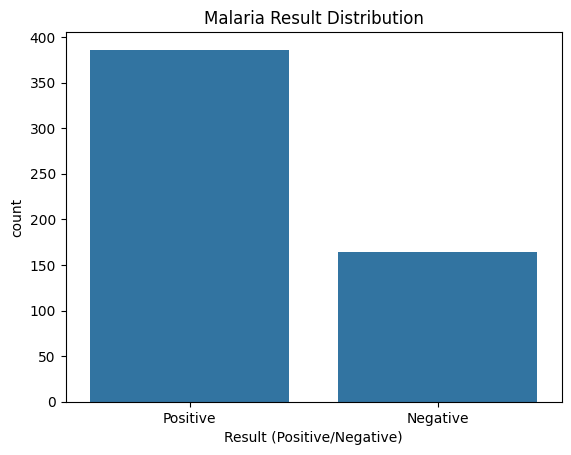

In [30]:
print(data["Result (Positive/Negative)"].value_counts())

sns.countplot(x="Result (Positive/Negative)", data=data)
plt.title("Malaria Result Distribution")
plt.show()

In [31]:
encoder = LabelEncoder()

data["Gender (F/M)"] = encoder.fit_transform(data["Gender (F/M)"])

data["PregNAPPnt Status (PW/NPW/NAPP)"] = encoder.fit_transform(data["PregNAPPnt Status (PW/NPW/NAPP)"])

data["Travel History (Yes/No)"] = encoder.fit_transform(data["Travel History (Yes/No)"])

data["Previous Malaria History (Yes/No)"] = encoder.fit_transform(
    data["Previous Malaria History (Yes/No)"]
)

data["Result (Positive/Negative)"] = encoder.fit_transform(data["Result (Positive/Negative)"])

In [32]:
X = data.drop("Result (Positive/Negative)", axis=1)

y = data["Result (Positive/Negative)"]

print(X.head())

   Age  Gender (F/M)  PregNAPPnt Status (PW/NPW/NAPP)  Temp (°C)  \
0   22             0                                1       36.9   
1   33             1                                0       39.1   
2   47             1                                0       38.6   
3   15             0                                1       37.9   
4   25             1                                0       38.5   

   Travel History (Yes/No)  Previous Malaria History (Yes/No)  
0                        1                                  1  
1                        0                                  1  
2                        1                                  1  
3                        0                                  0  
4                        0                                  0  


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (440, 6)
Testing samples: (110, 6)


In [34]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("After SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
Result (Positive/Negative)
1    308
0    132
Name: count, dtype: int64
After SMOTE:
Result (Positive/Negative)
1    308
0    308
Name: count, dtype: int64


In [35]:
scaler = StandardScaler()

X_train_smote = scaler.fit_transform(X_train_smote)

X_test = scaler.transform(X_test)

In [36]:
lr = LogisticRegression()

lr.fit(X_train_smote, y_train_smote)

lr_pred = lr.predict(X_test)

In [37]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_smote, y_train_smote)

dt_pred = dt.predict(X_test)

In [38]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_smote, y_train_smote)

knn_pred = knn.predict(X_test)

In [39]:
ann = MLPClassifier(hidden_layer_sizes=(10,10), max_iter=500)

ann.fit(X_train_smote, y_train_smote)

ann_pred = ann.predict(X_test)

In [40]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train_smote, y_train_smote)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 1.0


In [41]:
svm_model = SVC(
    kernel="rbf",
    C=1,
    gamma="scale"
)

svm_model.fit(X_train_smote, y_train_smote)

svm_pred = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.9454545454545454


In [21]:
lr_acc = accuracy_score(y_test, lr_pred)

dt_acc = accuracy_score(y_test, dt_pred)

knn_acc = accuracy_score(y_test, knn_pred)

ann_acc = accuracy_score(y_test, ann_pred)

print("Logistic Regression Accuracy:", lr_acc)
print("Decision Tree Accuracy:", dt_acc)
print("KNN Accuracy:", knn_acc)
print("ANN Accuracy:", ann_acc)

Logistic Regression Accuracy: 0.8545454545454545
Decision Tree Accuracy: 1.0
KNN Accuracy: 0.8818181818181818
ANN Accuracy: 0.990909090909091


In [43]:
print("Logistic Regression Report")
print(classification_report(y_test, lr_pred))

print("Decision Tree Report")
print(classification_report(y_test, dt_pred))

print("KNN Report")
print(classification_report(y_test, knn_pred))

print("ANN Report")
print(classification_report(y_test, ann_pred))

print("Random Forest Report")
print(classification_report(y_test, rf_pred))

print("SVM Report")
print(classification_report(y_test, svm_pred))


Logistic Regression Report
              precision    recall  f1-score   support

           0       0.72      0.81      0.76        32
           1       0.92      0.87      0.89        78

    accuracy                           0.85       110
   macro avg       0.82      0.84      0.83       110
weighted avg       0.86      0.85      0.86       110

Decision Tree Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        32
           1       1.00      1.00      1.00        78

    accuracy                           1.00       110
   macro avg       1.00      1.00      1.00       110
weighted avg       1.00      1.00      1.00       110

KNN Report
              precision    recall  f1-score   support

           0       0.76      0.88      0.81        32
           1       0.95      0.88      0.91        78

    accuracy                           0.88       110
   macro avg       0.85      0.88      0.86       110
weighted avg   

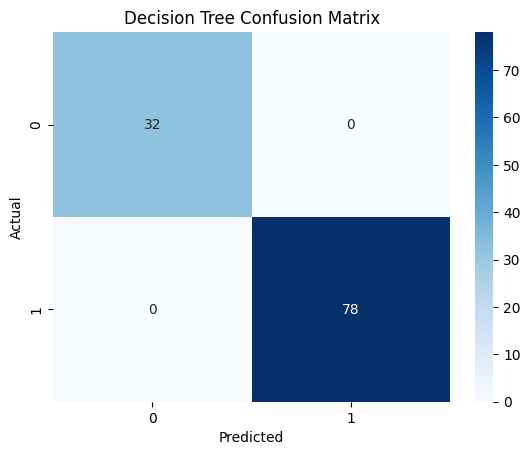

In [55]:
cm = confusion_matrix(y_test, dt_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

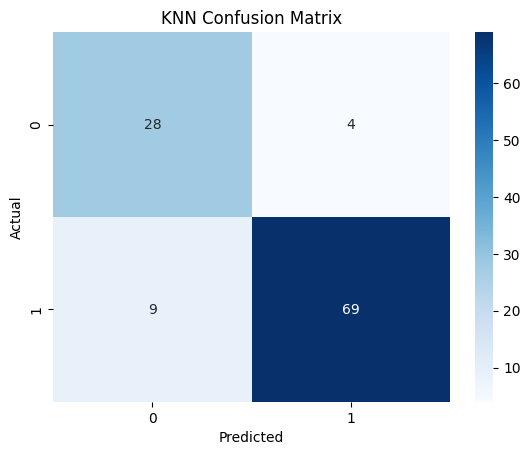

In [52]:
cm_knn = confusion_matrix(y_test, knn_pred)

sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues")

plt.title("KNN Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

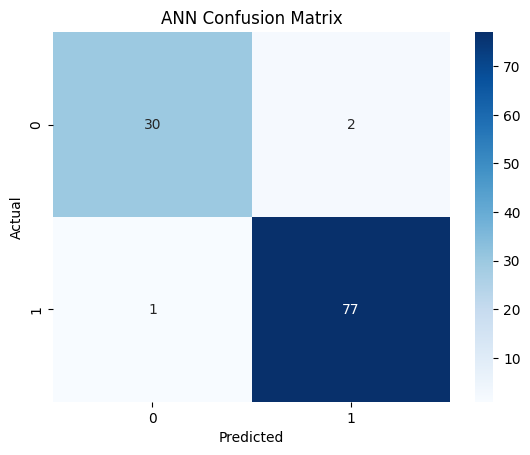

In [53]:
cm_ann = confusion_matrix(y_test, ann_pred)

sns.heatmap(cm_ann, annot=True, fmt="d", cmap="Blues")

plt.title("ANN Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

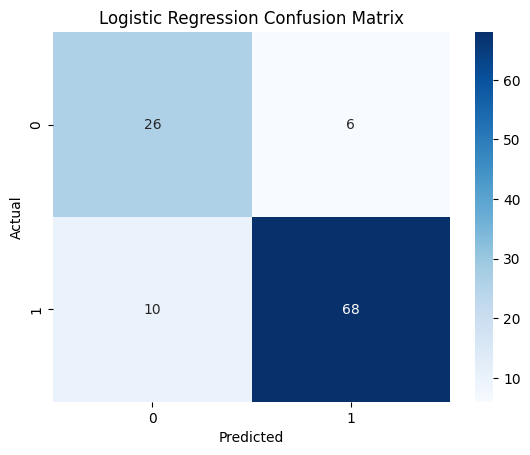

In [50]:
cm_lr = confusion_matrix(y_test, lr_pred)

sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

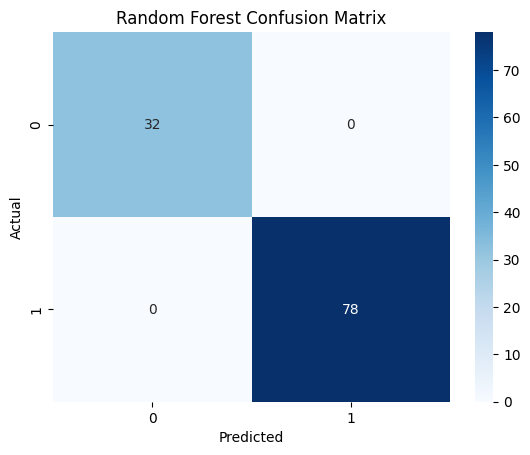

In [49]:
cm_rf = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [46]:
models = [
    "Logistic Regression",
    "Decision Tree",
    "KNN",
    "Neural Network",
    "Random Forest",
    "SVM"
]

accuracies = [
    lr_acc,
    dt_acc,
    knn_acc,
    ann_acc,
    rf_accuracy,
    svm_accuracy
]

results = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracies
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.854545
1        Decision Tree  1.000000
2                  KNN  0.881818
3       Neural Network  0.990909
4        Random Forest  1.000000
5                  SVM  0.945455


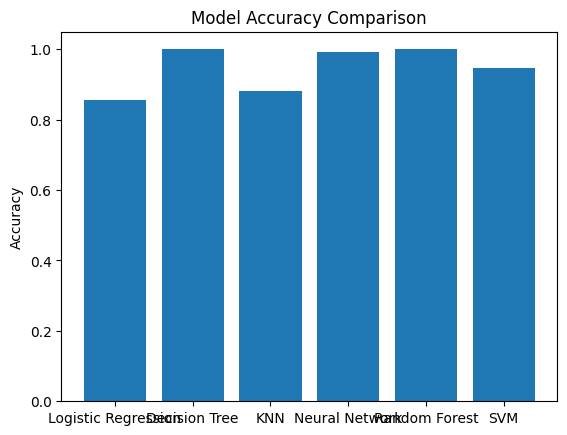

In [47]:
plt.figure()

plt.bar(results["Model"], results["Accuracy"])

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

In [48]:
importances = rf_model.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
})

print(importance_df.sort_values(by="Importance", ascending=False))

                             Feature  Importance
3                          Temp (°C)    0.696473
4            Travel History (Yes/No)    0.118942
5  Previous Malaria History (Yes/No)    0.116284
0                                Age    0.048722
1                       Gender (F/M)    0.013593
2    PregNAPPnt Status (PW/NPW/NAPP)    0.005986
